# Proyecto INE

## Indice

1. [Introduccion](#introduccion)
2. [Marco Teorico](#marco-teorico)
3. [Analisis Temporal](#analisis-temporal)
4. [Analisis por Tramo de Edad]
5. [Conclusiones]
6. [Anexo](#anexo)

## Introduccion 

In [43]:
# Modules to use
import pandas as pd
import seaborn as sns
import numpy as np
import scipy
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
# Load database
data = pd.read_csv("ano-2025.csv", sep=";")
data.head()

C:\Users\crist\AppData\Local\Temp\ipykernel_11976\3571564669.py:11: DtypeWarning: Columns (28,43,69,77,81,119,150,155,162,164) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("ano-2025.csv", sep=";")


,ano_trimestre,mes_central,ano_encuesta,mes_encuesta,region,provincia,tipo,r_p_c,estrato,conglomerado,...,efectivas,tpi,ocup_form,sector,r_p_rev4cl_caenes,ftp,obe,id,asocia,fact_anual
0,2025,2,2025,1,15,151,1,15101,15000012,16230,...,44.0,0.0,2.0,1.0,15.0,NaN,0.0,NaN,0.0,"16,9307528055373"
1,2025,2,2025,1,15,151,1,15101,15000012,16230,...,44.0,0.0,1.0,1.0,9.0,NaN,0.0,NaN,0.0,"19,8570154818132"
2,2025,2,2025,1,15,151,1,15101,15000012,16230,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,"17,2612656164794"
3,2025,2,2025,1,15,151,1,15101,15000012,16230,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,"15,4560029879504"
4,2025,2,2025,1,15,151,1,15101,15000012,16230,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,"14,0544783242967"


Una vez cargada la base de datos, observamos el tamaño de esta y los valores que puede tener la variable "activ", que describe la situacion laboral de cada una de las personas encuestadas

In [44]:
print(data.shape)
data["activ"].value_counts().keys()

(390903, 185)


Index([1.0, 3.0, 2.0], dtype='float64', name='activ')

## Marco Teorico
Podemos notar que la variable sobre la situacion laboral de cada uno de los encuestados tiene 3 opciones, las cuales segun el INE son:

- 1: Ocupado
- 2: Desocupado
- 3: Fuera de la fuerza del trabajo

En base a estas opciones, el INE calcula la tasa de desocupacion y de ocupacion a partir de los datos obtenidos, utilizando las siguientes formulas

$$TD = \frac{DO}{FT} * 100$$
Donde,

$DO = $ Personas desocupadas

$FT = $ Fuerza del trabajo

$$TO = \frac{O}{PET} * 100$$

Donde, 

$O = $ Personas ocupadas

$PET = $ Personas en edad de trabajar (15 años en adelante)

Por lo tanto, como solo se considera la fuerza del trabajo para la desocupacion, en este grupo solo se consideran las primeras dos respuestas. De este modo, se pueden definir las variables $X_1,..., X_n$ que valen 1 si la i-esima persona esta desocupada o 0 si esta ocupada. Ademas, es posible notar que las variables no dependen entre si, por lo que podemos concluir que

$$X_1,..., X_n \overset{iid}{\sim} Bernoulli(p_D)$$

Ahora, podemos utilizar el estimador de maxima verosimilitud (EMV) de la distribucion de Bernoulli, el cual esta dado por

$$\hat{p}_D = \sum_{i = 1}^n \frac{X_i}{n} = \bar{X}$$

Es decir, el promedio muestral de las personas desocupadas que se encuentran dentro de la fuerza del trabajo, lo que coincide con la formula de la tasa de desocupacion, por lo que se puede calcular el EMV facilmente con este resultado. A partir de esto es que se calcularan intervalos de confianza y se realizaran las pruebas de hipotesis.

De la misma forma, para la tasa de ocupacion ahora estan las tres opciones, por lo que podemos definir las variables $Y_1,..., Y_n$ identicamente distribuidas con la siguiente funcion de densidad.

$$f(y) = p_1^{\frac{(y-2)(y-3)}{(1-2)(1-3)}} p_2^{\frac{(y-1)(y-3)}{(2-1)(2-3)}} p_3^{\frac{(y-1)(y-2)}{(3-1)(3-2)}}, \ \ \ y = 1, 2, 3, \ \ \ p_1 + p_2 + p_3 = 1$$

donde $p_1$, $p_2$ y $p_3$ son las probabilidades de que una persona se encuentre ocupada, desocupada o fuera de la fuerza del trabajo respectivamente. En base a esta funcion de densidad, podemos calcular el EMV para $p_1$ y su distribucion asintotica (desarrollo en el anexo), los cuales estan dados por:

$$\hat{p}_1 = \frac{TO}{PET}$$
$$\hat{p}_1 \overset{a}{\sim} N(p_1, \frac{p_1}{n})$$



## Analisis Temporal
En esta seccion queremos responder las siguiente pregunta

> ¿Han cambiado la tasas de desocupacion y ocupacion en Chile durante el año 2025?

Para esto, se analizara el cambio de estas tasas a lo largo de los meses del año y se realizarán análisis estadísticos para recopilar evidencia para responder estas preguntas. En primer lugar, analicemos la tasa de desocupación

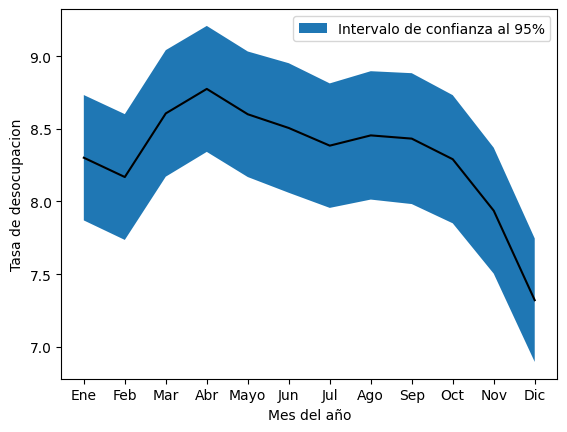

In [60]:
def ic(df: pd.DataFrame):
    alpha = 0.05
    cuantil = scipy.stats.norm.ppf(1-alpha/2)
    td = len(df[df["activ"] == 2]) / len(df)
    error = cuantil * np.sqrt(td * (1 - td) / len(df))
    return [(td - error) * 100, (td + error) * 100]

fuerza_trabajo = data[(data["activ"] != 3) & (data["activ"].notnull())]
meses = ["Ene", "Feb", "Mar", "Abr", 
         "Mayo", "Jun", "Jul", "Ago",
         "Sep", "Oct", "Nov", "Dic"]
data_mensual = fuerza_trabajo.groupby("mes_encuesta")

tasas_desocupacion = data_mensual.apply(lambda df: len(df[df["activ"] == 2]) / len(df) * 100)
ics_95 = data_mensual.apply(ic)
ic_inf = []
ic_sup = []
for ic_95 in ics_95:
    ic_inf.append(ic_95[0])
    ic_sup.append(ic_95[1])
plt.plot(meses, tasas_desocupacion.values, color="black")
plt.xlabel("Mes del año")
plt.ylabel("Tasa de desocupacion")

plt.fill_between(meses, ic_inf, ic_sup, label = "Intervalo de confianza al 95%")
plt.legend()
plt.show()

Ahora, debemos

## Anexo
$$\sup L(p_1, p_2, p_3) \\ \text{sujeto a} \ \ \ p_1 + p_2 + p_3 = 1$$

donde L es la funcion de verosimilitud. Ahora, dado que la funcion logaritmo natural es estrictamente creciente, la expresion anterior es equivalente a calcular

$$\sup l(p_1, p_2, p_3) = \sup \ln (L(p_1, p_2, p_3)) \\ \text{sujeto a} \ \ \ p_1 + p_2 + p_3 = 1$$

Ahora, la funcion de verosimilitud esta dada por

\begin{align*}
    L(p_1, p_2, p_3) &= f(p_1, p_2, p_3 | \mathbf{Y}) \\
    & = \prod_{i = 1}^n f(y_i) \\
    & = \prod_{i = 1}^n p_1^{\frac{(y_i-2)(y_i-3)}{(1-2)(1-3)}} p_2^{\frac{(y_i-1)(y_i-3)}{(2-1)(2-3)}} p_3^{\frac{(y_i-1)(y_i-2)}{(3-1)(3-2)}} \\
    & = p_1^{\sum_{i = 1}^n \frac{(y_i - 2)(y_i -3)}{(1 - 2)(1 - 3)}} p_2^{\sum_{i = 1}^n \frac{(y_i - 1)(y_i -3)}{(2 - 1)(2 - 3)}} p_3^{\sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)}}
\end{align*}

por lo que la funcion de log-verosimilitud se calcula como

\begin{align*}
    l(p_1, p_2, p_3) = \sum_{i = 1}^n \frac{(y_i - 2)(y_i -3)}{(1 - 2)(1 - 3)} \ln(p_1) + \sum_{i = 1}^n \frac{(y_i - 1)(y_i -3)}{(2 - 1)(2 - 3)} \ln(p_2) + \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)} \ln(p_3) 
\end{align*}

Luego, como queremos calcular el calcular el supremo dada la restriccion de las probabilidades, entonces calculamos el lagrangiano

$$L(p_1, p_2, p_3, \lambda) = l(p_1, p_2, p_3) - \lambda (p_1 + p_2 + p_3 - 1)$$

de modo que obtenemos las condiciones de Lagrange

$$\frac{\partial L}{\partial p_1} = \sum_{i = 1}^n \frac{(y_i - 2)(y_i -3)}{(1 - 2)(1 - 3)} \frac{1}{p_1} - \lambda = 0$$
$$\frac{\partial L}{\partial p_2} = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 3)}{(2 - 1)(2 - 3)} \frac{1}{p_2} - \lambda = 0$$
$$\frac{\partial L}{\partial p_1} = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)} \frac{1}{p_3} - \lambda = 0$$
$$\frac{\partial L}{\partial \lambda} = p_1 + p_2 + p_3 - 1 = 0$$

De estas ecuaciones, obtenemos que

$$p_1 = \frac{\sum_{i = 1}^n (y_i - 2)(y_i - 3)}{\lambda (1 - 2)(1 - 3)}$$
$$p_2 = \frac{\sum_{i = 1}^n (y_i - 1)(y_i - 3)}{\lambda (2 - 1)(2 - 3)}$$
$$p_3 = \frac{\sum_{i = 1}^n (y_i - 1)(y_i - 2)}{\lambda (3 - 1)(3 - 2)}$$

por lo que podemos reemplazar estos valores en la restriccion de igualdad

$$ \frac{1}{\lambda} \left(\sum_{i = 1}^n \frac{(y_i - 2)(y_i - 3)}{(1 - 2)(1 - 3)} + \frac{(y_i - 1)(y_i - 3)}{(2 - 1)(2 - 3)} + \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)}\right) = 1 $$

donde podemos notar que se cumple la siguiente igualdad

$$\frac{(y_i - 2)(y_i - 3)}{(1 - 2)(1 - 3)} + \frac{(y_i - 1)(y_i - 3)}{(2 - 1)(2 - 3)} + \frac{(y_i - 1)(y_i - 2)}{(3 - 1)(3 - 2)} = 1$$

por lo que al reemplazar en la ecuacion anterior nos queda

$$\frac{1}{\lambda} \sum_{i = 1}^n 1 = \frac{n}{\lambda} = 1$$
$$\lambda = n$$

de modo que los EMV para cada probalidad son

$$\hat{p}_1 = \sum_{i = 1}^n \frac{(y_i - 2)(y_i - 3)}{n(1 - 2)(1 - 3)}$$
$$\hat{p}_2 = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 3)}{n(2 - 1)(2 - 3)}$$
$$\hat{p}_3 = \sum_{i = 1}^n \frac{(y_i - 1)(y_i - 2)}{n(3 - 1)(3 - 2)}$$

Ademas, por la construccion de la funcion densidad basada en los polinomios de Lagrange, para cada EMV se suma solo 1 por cada persona que contesta la opcion asignada a dicha probabilidad, por lo que los EMV se puede calcular como la proporcion de personas que contesta cada una de las 3 opciones posibles. Es decir, si se considera el grupo de las personas en edad de trabajar, el EMV de $p_1$ se calcula como

$$\hat{p}_1 = \frac{TO}{PET}$$

Luego, para realizar los intervalos de confianza y test de hipotesis, utilizamos la normalidad asintotica que caracteriza a los EMV, por lo que debemos calcular la matriz de informacion de Fisher

\begin{align*}
    \begin{bmatrix}
        \frac{n}{p_1} & 0 & 0 \\
        0 & \frac{n}{p_2} & 0 \\
        0 & 0 & \frac{n}{p_3}
    \end{bmatrix}
\end{align*}